**ANÁLISIS SERIE TEMPORAL DE GENERACIÓN DEL INVERSOR**
1. Serie completa
- Estacionalidad
- Tendencia

In [14]:
import pandas as pd
df = pd.read_csv('inverter_horario_clean.csv')
df.head()

,date_time,date,time,weekday,inverterPower
0,2024-02-17 03:00:00,2024-02-17,03:00,Saturday,0.0
1,2024-02-17 04:00:00,2024-02-17,04:00,Saturday,0.0
2,2024-02-17 05:00:00,2024-02-17,05:00,Saturday,0.0
3,2024-02-17 06:00:00,2024-02-17,06:00,Saturday,0.0
4,2024-02-17 07:00:00,2024-02-17,07:00,Saturday,0.0


In [15]:
df.dtypes

date_time         object
date              object
time              object
weekday           object
inverterPower    float64
dtype: object

In [16]:
# Intervalo de datos
index_fecha_min = df['date_time'].idxmin()
index_fecha_max = df['date_time'].idxmax()
df.iloc[[index_fecha_min, index_fecha_max]]

,date_time,date,time,weekday,inverterPower
0,2024-02-17 03:00:00,2024-02-17,03:00,Saturday,0.0
8996,2025-02-25 23:00:00,2025-02-25,23:00,Tuesday,0.0


## Análisis descriptivo básico

In [17]:
df.describe()

,inverterPower
count,8997.000000
mean,0.337392
std,0.524752
min,0.000000
25%,0.000000
50%,0.020000
75%,0.480000
max,3.040000


In [18]:
# Hora de mayor producción
index_max = df['inverterPower'].idxmax()
df[index_max:index_max+1]

,date_time,date,time,weekday,inverterPower
3490,2024-07-11 14:00:00,2024-07-11,14:00,Thursday,3.04


In [19]:
# Producción diaria media
df_media_diaria = df.where(df['time'].isin(['09:00','10:00','11:00','12:00','13:00','14:00','15:00','16:00','17:00','18:00','19:00'])).groupby('date')['inverterPower'].mean().reset_index()
df_media_diaria.describe()


,inverterPower
count,375.000000
mean,0.719176
std,0.330668
min,0.120909
25%,0.454091
50%,0.672727
75%,0.962273
max,1.683636


In [20]:
df_media_diaria['date'] = pd.to_datetime(df_media_diaria['date'])
df_media_diaria.dtypes

date             datetime64[ns]
inverterPower           float64
dtype: object

In [21]:
# días de menor y mayor producción media
index_prod_min = df_media_diaria['inverterPower'].idxmin()
index_prod_max = df_media_diaria['inverterPower'].idxmax()
df_media_diaria.iloc[[index_prod_min, index_prod_max]]

,date,inverterPower
339,2025-01-21,0.120909
159,2024-07-25,1.683636


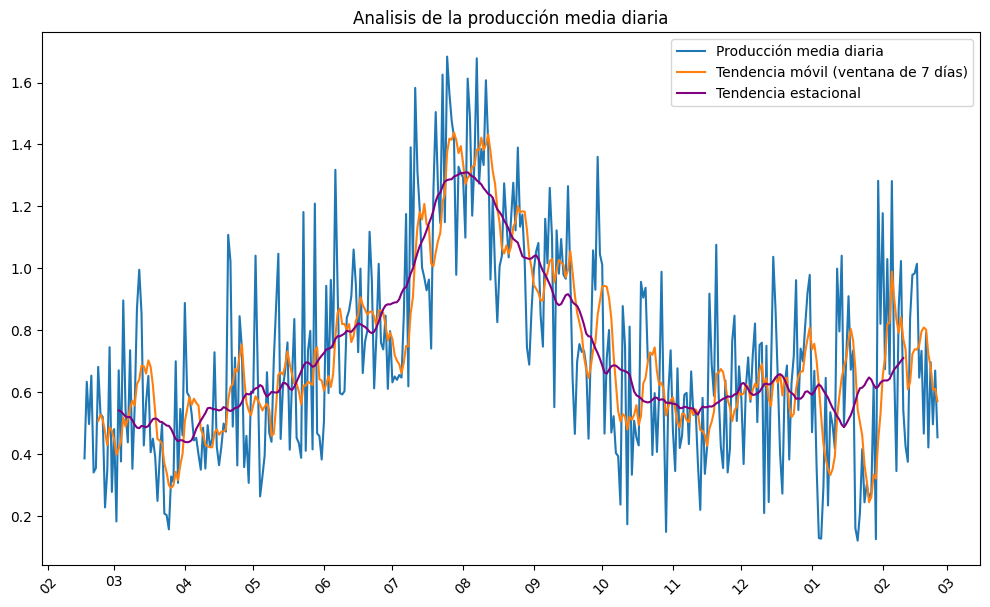

In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.tsa.seasonal as seasonal_decompose

ventana = 7
df_media_diaria['tendencia_movil'] = df_media_diaria['inverterPower'].rolling(window=ventana).mean()

decomposition = seasonal_decompose.seasonal_decompose(df_media_diaria['inverterPower'], model='additive', period=30)

fig, ax = plt.subplots(figsize=(10, 6))
month_locator = mdates.MonthLocator()
date_formatter = mdates.DateFormatter('%m')
ax.xaxis.set_major_locator(month_locator)
ax.xaxis.set_major_formatter(date_formatter)
plt.xticks(rotation=45)
plt.tight_layout()
plt.plot(df_media_diaria['date'], df_media_diaria['inverterPower'], label='Producción media diaria')
plt.plot(df_media_diaria['date'], df_media_diaria['tendencia_movil'], label='Tendencia móvil (ventana de 7 días)')
plt.plot(df_media_diaria['date'], decomposition.trend, color='purple', label='Tendencia estacional')
plt.title('Analisis de la producción media diaria')
plt.legend()
plt.show()